# The grand tour: composing every shift term in one scenario

![CliffordClock showcase animation: Monte Carlo atoms dispersing through a real chamber field, colored by accumulated fractional shift, with the ensemble coherence decaying at T2*](../docs/assets/showcase_animation.gif)

Every other notebook in this project isolates one physics term and checks it
against one published number: NPL's stray field (notebook 06), JILA's
blackbody row (notebook 07), Roos's quadrupole slope (notebook 08),
Bothwell's millimetre-scale redshift (notebook 09). This notebook does the
opposite. It takes a single physical scenario, the paper's showcase chamber
field and its Sr-87 cloud, and walks it through every term this project
ships, one at a time, in the order a real evaluation would add them: the
static DC-Stark shift from the chamber's own field curvature, the
blackbody-radiation shift from the chamber walls, the gravitational
redshift across the cloud, a cross-check of the whole accumulated
calculation through the independent Cl(1,3) rotor engine, and finally the
same gravity term recovered from an extended optical-lattice sample the way
Bothwell's apparatus actually measures it. No textbook formula gives this
composition directly; each term is checked in isolation elsewhere in this
project, and what only a real pipeline run can show is that they all add
into the same scalar pivot, on the same atoms, without stepping on each
other. The animation above is the fast, visual version of stage 1 below:
real Monte Carlo atoms moving through the real chamber field, colored by
the shift they are accumulating as they go, with the ensemble's coherence
decaying alongside it.

In [1]:
# The animation above is generated (not run here -- it takes about a
# minute and this notebook does not need a fresh copy) by:
print("python examples/generate_showcase_animation.py")

python examples/generate_showcase_animation.py


## 1. The scenario: the showcase chamber field

The field this whole notebook runs on is `examples/showcase_field.txt`, a
chamber-scale electrostatic field built to have genuine spatial structure:
two electrode plates of different size and voltage at non-mirror-symmetric
positions, plus a small patch-potential spot embedded in one wall (a
standard model of trapped-charge contamination), solved from scratch by
finite differences (`examples/generate_showcase_field.py`) and loaded
through the same COMSOL-format loader a lab's own FEA export would use.
`examples/showcase_gradient_dispersion_sr87.yaml`, the paper's own showcase
config (`paper/figures/fig4_showcase_gradient_dispersion.py`), pins a
classical, chamber-scale Sr-87 cloud (`omega_xyz = 100 rad/s`, `T = 50 uK`)
whose thermal size is deliberately scaled to be a real fraction of the
field's own curvature, so a Monte Carlo atom drifting through it genuinely
samples that structure. Every
stage below starts from that same config and adds exactly one more term.


In [2]:
%matplotlib inline
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from cliffordclock.constants import SPEED_OF_LIGHT, STANDARD_GRAVITY
from cliffordclock.ensemble.species import get_species
from cliffordclock.integrator.omega import bbr_pivot_perturbation as bbr_pivot_direct
from cliffordclock.integrator.omega import grav_pivot_perturbation, height_along_axis
from cliffordclock.pipeline import (
    GravityConfig,
    PipelineConfig,
    _auto_renorm_every,
    _build_field_fn,
    _resolve_bbr_pivot_perturbation,
    _resolve_stark_coupling,
    _stark_rotor_ensemble,
    run_pipeline_full,
)

np.set_printoptions(precision=6, suppress=False)
EXAMPLES_DIR = Path("..") / "examples"

## 2. Stage 1: DC Stark alone

The first stage is exactly the paper's showcase run, `ensemble.regime:
classical` propagating Maxwell-Boltzmann-sampled Sr-87 atoms through the
fitted chamber field via velocity-Verlet trajectories, with one change: the
ensemble is reduced from the paper's 100 atoms to 48, purely for this
notebook's runtime, keeping every physical parameter (species, trap,
temperature, field, interrogation window) identical to the shipped,
memory-safety-checked config.


In [3]:
config = PipelineConfig.from_yaml(EXAMPLES_DIR / "showcase_gradient_dispersion_sr87.yaml")
# Path fix-up (the shipped YAML assumes repo-root invocation; this
# notebook's cwd is notebooks/) plus the reduced ensemble size below --
# every other physical parameter (species, trap, temperature,
# integration.dtau/steps) is unchanged from the shipped, memory-safety-
# checked config (examples/showcase_gradient_dispersion_sr87.yaml).
N_ATOMS_DEMO = 48  # reduced from the shipped config's 100, for this notebook's runtime
config = replace(
    config,
    field_config=replace(
        config.field_config, comsol_path=str((EXAMPLES_DIR / "showcase_field.txt").resolve())
    ),
    ensemble=replace(config.ensemble, size=N_ATOMS_DEMO),
)
species = get_species(config.species)
trap_center_m = np.asarray(config.trap.center)

stage1_config = config
stage1_result = run_pipeline_full(stage1_config)
report1 = stage1_result.report

print(f"ensemble_type:          {report1.ensemble_type}")
print(f"atoms in this run:      {N_ATOMS_DEMO} (paper's showcase config uses 100)")
print(f"interrogation_time_s:   {report1.interrogation_time_s:.6f}")
print(
    f"mean_fractional_shift:  {report1.mean_fractional_shift:+.6e} "
    f"+/- {report1.shift_std_error:.3e} (SEM)"
)
print(f"t2_star_s:              {report1.t2_star_s:.6e} s")
print()
print("uncertainty_notes:")
print(report1.uncertainty_notes)

ensemble_type:          classical_direct
atoms in this run:      48 (paper's showcase config uses 100)
interrogation_time_s:   0.199805
mean_fractional_shift:  -1.005600e-16 +/- 1.043e-18 (SEM)
t2_star_s:              2.520694e-04 s

uncertainty_notes:
Paper showcase scenario (physical E14b DC-Stark coupling, Sr87 registry Delta_alpha, field loaded from examples/showcase_field.txt via the COMSOL loader and FieldSmoother -- see examples/generate_showcase_field.py for the field's physics/back-of-envelope check). This run reports the scalar "trajectory mode" evaluation only; the paper's Figure 4 and its generating script additionally cross-check this same scenario through the Cl(1,3) rotor accumulator directly (not expressible through this YAML config's integration.mode, which is lattice-only for the worldline/rotor path). No experimental-dataset comparison, no BBR modeling, no systematic-uncertainty budget beyond what coupling/mode provenance notes state. integration.mode=direct dtau=4.8

This is the same inhomogeneous-shift budget notebook 05 walks in full: a
mean fractional shift set by the chamber field's average curvature under
the cloud, a spread (and the resulting T2*) set by how differently each of
the 48 atoms' own trajectories sample that curvature, not by any stochastic
process. `uncertainty_notes` records exactly what went into this number:
the physical E14b DC-Stark coupling, the Sr-87 registry's `Delta_alpha`,
and nothing else yet, since every later stage adds one more sentence to
this same note as it composes in.


## 3. Stage 2: compose blackbody radiation

Every real vacuum chamber is warm, and the walls' thermal radiation shifts
the clock transition through the same second-order Stark mechanism as the
static field, just averaged over the thermal photon bath (E32,
`docs/CONVENTIONS.md` section 13). Setting `environment.radiation_temperature_K`
(plus its 1-sigma uncertainty) on the identical stage-1 config, with every
other parameter untouched, reruns the same 48 trajectories through a
pipeline that now composes the BBR term additively into the same scalar
pivot the DC-Stark term already occupies.


In [4]:
ROOM_TEMPERATURE_K = 300.0
ROOM_TEMPERATURE_UNCERTAINTY_K = 1.0

stage2_config = replace(
    stage1_config,
    environment=replace(
        stage1_config.environment,
        radiation_temperature_k=ROOM_TEMPERATURE_K,
        radiation_temperature_uncertainty_k=ROOM_TEMPERATURE_UNCERTAINTY_K,
    ),
)
stage2_result = run_pipeline_full(stage2_config)
report2 = stage2_result.report

bbr_delta = report2.mean_fractional_shift - report1.mean_fractional_shift
bbr_direct_value = bbr_pivot_direct(ROOM_TEMPERATURE_K, species)

print(
    f"mean_fractional_shift:  {report2.mean_fractional_shift:+.6e} "
    f"+/- {report2.shift_std_error:.3e} (SEM)"
)
print(f"t2_star_s:              {report2.t2_star_s:.6e} s")
print()
print(f"stage 2 - stage 1 (BBR term, from the pipeline):  {bbr_delta:+.6e}")
print(f"bbr_pivot_perturbation({ROOM_TEMPERATURE_K:.0f} K) direct call:   {bbr_direct_value:+.6e}")
print(f"agreement (abs diff):                             {abs(bbr_delta - bbr_direct_value):.3e}")
print()
print("uncertainty_notes:")
print(report2.uncertainty_notes)

mean_fractional_shift:  -5.420064e-15 +/- 1.043e-18 (SEM)
t2_star_s:              2.520694e-04 s

stage 2 - stage 1 (BBR term, from the pipeline):  -5.319504e-15
bbr_pivot_perturbation(300 K) direct call:   -5.319504e-15
agreement (abs diff):                             7.889e-31

uncertainty_notes:
Paper showcase scenario (physical E14b DC-Stark coupling, Sr87 registry Delta_alpha, field loaded from examples/showcase_field.txt via the COMSOL loader and FieldSmoother -- see examples/generate_showcase_field.py for the field's physics/back-of-envelope check). This run reports the scalar "trajectory mode" evaluation only; the paper's Figure 4 and its generating script additionally cross-check this same scenario through the Cl(1,3) rotor accumulator directly (not expressible through this YAML config's integration.mode, which is lattice-only for the worldline/rotor path). No experimental-dataset comparison, no BBR modeling, no systematic-uncertainty budget beyond what coupling/mode provenan

The mean shift moves by exactly the BBR term the direct
`bbr_pivot_perturbation` call predicts, to within floating-point roundoff,
which is the additive-composition guarantee (E33: no DC-Stark/BBR cross
term at this project's working precision) showing up as a real number. `uncertainty_notes` has grown a new sentence: the
BBR provenance line, naming the static and dynamic coefficients' citations
and folding the temperature uncertainty into the reported budget, appended
to (not replacing) the DC-Stark provenance stage 1 already printed.


## 4. Stage 3: compose gravity

A clock higher in a gravitational potential runs faster than one lower
down (E36, `docs/CONVENTIONS.md` section 15), and this term composes into
the same pivot the same way BBR just did: additively, with no cross term,
evaluated from each atom's own position. Setting `environment.gravity` on the stage-2
config (standard gravity, "up" along the chamber's own z axis, referenced
to the cloud's trap center so the reported shift is centered on zero)
adds a third term to the same 48 trajectories.

One labeling point matters here, per `docs/CONVENTIONS.md` section 15's
binding ruling for the `lattice_extended` regime (stage 5 below): a
height-dependent shift like this one is a deterministic gradient
correlated with each atom's own position, not additional stochastic
dephasing, even though this classical scenario's `t2_star_s`/
`shift_std_error` do not separately break it out the way
`lattice_extended`'s site map does. The plot below keeps that distinction
explicit by showing the per-atom shift against height directly.


mean_fractional_shift:  -5.420064e-15 +/- 1.043e-18 (SEM)
t2_star_s:              2.520436e-04 s

gravity term, max abs diff (pipeline vs. direct grav_pivot_perturbation): 5.815e-22


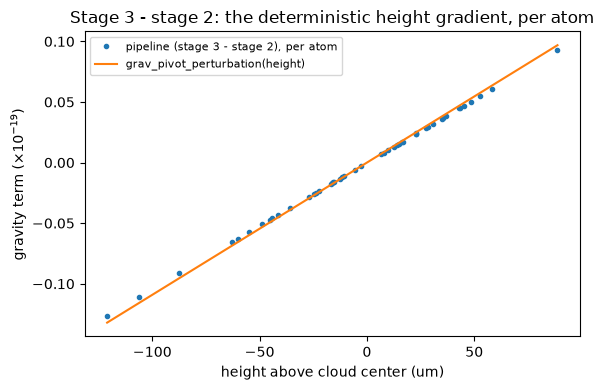

In [5]:
stage3_config = replace(
    stage2_config,
    environment=replace(
        stage2_config.environment,
        gravity=GravityConfig(
            g_m_s2=STANDARD_GRAVITY,
            up_axis=(0.0, 0.0, 1.0),
            reference_height_m=float(trap_center_m[2]),
        ),
    ),
)
stage3_result = run_pipeline_full(stage3_config)
report3 = stage3_result.report

print(
    f"mean_fractional_shift:  {report3.mean_fractional_shift:+.6e} "
    f"+/- {report3.shift_std_error:.3e} (SEM)"
)
print(f"t2_star_s:              {report3.t2_star_s:.6e} s")

# Per-atom check: the gravity term added between stage 2 and stage 3 should
# match grav_pivot_perturbation evaluated at each atom's own MEAN height,
# exactly (E36 is linear in height, so time-averaging commutes with it).
mean_position_per_atom = np.asarray(stage3_result.trajectories).mean(axis=1)  # (M, 3)
up_axis = np.array([0.0, 0.0, 1.0])
heights_m = np.asarray(height_along_axis(mean_position_per_atom, up_axis))
analytic_grav_shift = np.asarray(
    grav_pivot_perturbation(heights_m, STANDARD_GRAVITY, float(trap_center_m[2]))
)
pipeline_grav_shift = np.asarray(stage3_result.ensemble_result.fractional_shift) - np.asarray(
    stage2_result.ensemble_result.fractional_shift
)
print()
print(
    "gravity term, max abs diff (pipeline vs. direct grav_pivot_perturbation): "
    f"{np.max(np.abs(pipeline_grav_shift - analytic_grav_shift)):.3e}"
)

height_um = (heights_m - float(trap_center_m[2])) * 1e6
order = np.argsort(height_um)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(
    height_um[order],
    pipeline_grav_shift[order] * 1e19,
    ".",
    color="C0",
    label="pipeline (stage 3 - stage 2), per atom",
)
ax.plot(
    height_um[order],
    analytic_grav_shift[order] * 1e19,
    color="C1",
    label="grav_pivot_perturbation(height)",
)
ax.set_xlabel("height above cloud center (um)")
ax.set_ylabel(r"gravity term ($\times 10^{-19}$)")
ax.set_title("Stage 3 - stage 2: the deterministic height gradient, per atom")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Every point falls on the analytic `grav_pivot_perturbation` line to well
below plot resolution (the printed maximum deviation sits two orders of
magnitude under the term itself), which is the point: this is a
deterministic function of each atom's own average height in the trap,
not scatter. At chamber scale the height
spread is the cloud's own thermal extent (hundreds of micrometres, not the
millimetre span Bothwell's sample uses), so the term stays at the ~1e-20
level here, small enough to be invisible in the ensemble mean but exact
and fully recovered once plotted against height.


## 5. Stage 4: the rotor cross-check

Everything so far has run through the pipeline's scalar trajectory-mode
accumulator. `docs/CONVENTIONS.md`'s Cl(1,3) rotor engine is a
structurally different way to integrate the same physics: the trajectory
mode sums a scalar rate function, while the rotor engine advances a full
spacetime-algebra exponential map. Notebook 05 already establishes that
the two agree on the showcase scenario's DC-Stark term alone. This stage repeats that cross-check on the
*exact same* stage-3 trajectories, now carrying the composed DC-Stark +
BBR + gravity budget, by driving `_stark_rotor_ensemble` directly
(mirroring `paper/figures/fig4_showcase_gradient_dispersion.py` and
notebook 05's own head-to-head) with the same BBR and gravity values
threaded in as keyword arguments. Agreement here is a statement about the
*composed* calculation, not just the single term the earlier cross-check
covers.


In [6]:
field_fn, _n_fit_points = _build_field_fn(stage3_config.field_config)
stark_coeffs = _resolve_stark_coupling(stage3_config.coupling, species)
bbr_value, _bbr_note = _resolve_bbr_pivot_perturbation(stage3_config.environment, species)

trajectories = stage3_result.trajectories
dtau = stage3_config.integration.dtau
assert dtau is not None

ensemble_result_rotor = _stark_rotor_ensemble(
    field_fn,
    stark_coeffs,
    trajectories,
    dtau,
    renorm_every=_auto_renorm_every(),
    bbr_pivot_perturbation=bbr_value,
    gravity=stage3_config.environment.gravity,
)

shift_scalar = np.asarray(stage3_result.ensemble_result.fractional_shift)
shift_rotor = np.asarray(ensemble_result_rotor.fractional_shift)
max_abs_shift_diff = float(np.max(np.abs(shift_scalar - shift_rotor)))
mean_shift_rel_diff = abs(float(np.mean(shift_scalar)) - float(np.mean(shift_rotor))) / abs(
    float(np.mean(shift_scalar))
)

print(f"scalar-mode mean fractional shift: {np.mean(shift_scalar):+.6e}")
print(f"rotor-mode mean fractional shift:  {np.mean(shift_rotor):+.6e}")
print(f"max |scalar - rotor| per atom:     {max_abs_shift_diff:.3e}")
print(f"relative difference of means:      {mean_shift_rel_diff:.3e}")

scalar-mode mean fractional shift: -5.420064e-15
rotor-mode mean fractional shift:  -5.420064e-15
max |scalar - rotor| per atom:     7.889e-31
relative difference of means:      0.000e+00


Scalar and rotor modes agree far below the size of any term this notebook
composed in, on the full stacked calculation. Notebook 05 makes the same
check on the isolated DC-Stark term alone; this run carries all three
terms at once. That is the real message of this stage:
the two accumulators are structurally different integrators, not one a
fallback for the other, and they land on the same physics regardless of
how many terms are stacked into the pivot.


## 6. Stage 5: the extended-lattice view

Every stage above used a single, well-localized cloud, where gravity's own
contribution is a fraction of a linewidth. Bothwell's actual measurement
(notebook 09) does not localize the sample at all: it spreads Sr-87 across
a millimetre-scale optical lattice specifically so each site's own height
difference becomes the dominant, directly fittable signal. This stage
builds a small version of that same `ensemble.regime: lattice_extended`
geometry, about 100 sites spanning roughly a millimetre, with the field
switched off and gravity switched on, so the per-site frequency map is
gravity and nothing else, and the fitted slope should recover `g/c^2`
directly: the same E36 constant stage 3 added atom by atom. There it was
a small correction riding on top of a chamber field's Stark budget; here
it is the entire signal.


sites:                        101
sample extent:                1.000 mm
fitted slope:                 +1.0911370e-16 /m
g/c^2:                        +1.0911370e-16 /m
relative deviation:           4.519e-16

total_spread_fractional:                     3.197e-20
gradient_removed_residual_spread_fractional: 3.934e-36

lattice_extended dispersion labeling (CONVENTIONS.md section 15, G9 sign-off A4#2): this run's t2_star_s/shift_std_error (MetrologyReport) are computed over the FULL site-and-motional ensemble and therefore include the DETERMINISTIC per-site height gradient (higher/lower sites tick at a systematically different rate -- not a stochastic process, and in principle refocusable) mixed together with any genuine stochastic (motional-quadrature) spread. Use site_map.slope_per_m (the headline gradient) and site_map.total_spread_fractional / site_map.gradient_removed_residual_spread_fractional to separate them: total_spread_fractional is the SAME combined (deterministic + stochast

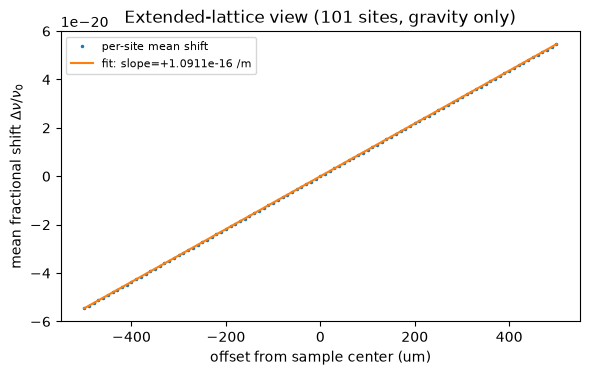

In [7]:
N_SITES_DEMO = 101  # ~100 sites
SITE_SPACING_M = 1.0e-5  # 10 um -- (N_SITES_DEMO - 1) * SITE_SPACING_M = 1.0 mm total extent

lattice_config = PipelineConfig.from_dict(
    {
        "species": "Sr87",
        "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5], "center": [0.0, 0.0, 0.0]},
        "field": {"synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, 0.0]}}},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice_extended",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": 1,
            "n_sites": N_SITES_DEMO,
            "site_spacing_m": SITE_SPACING_M,
            "site_axis": [0.0, 0.0, 1.0],
            "site_envelope": "uniform",
        },
        "integration": {"mode": "fast_path", "time_s": 1.0},
        "environment": {
            "gravity": {
                "g_m_s2": STANDARD_GRAVITY,
                "up_axis": [0.0, 0.0, 1.0],
                "reference_height_m": 0.0,
            }
        },
    }
)
lattice_result = run_pipeline_full(lattice_config)
site_map = lattice_result.site_map
assert site_map is not None

g_over_c2_per_m = STANDARD_GRAVITY / SPEED_OF_LIGHT**2
slope_rel_dev = abs(site_map.slope_per_m - g_over_c2_per_m) / g_over_c2_per_m

print(f"sites:                        {len(site_map.sites)}")
print(f"sample extent:                {(N_SITES_DEMO - 1) * SITE_SPACING_M * 1e3:.3f} mm")
print(f"fitted slope:                 {site_map.slope_per_m:+.7e} /m")
print(f"g/c^2:                        {g_over_c2_per_m:+.7e} /m")
print(f"relative deviation:           {slope_rel_dev:.3e}")
print()
print(f"total_spread_fractional:                     {site_map.total_spread_fractional:.3e}")
print(
    "gradient_removed_residual_spread_fractional: "
    f"{site_map.gradient_removed_residual_spread_fractional:.3e}"
)
print()
print(site_map.dispersion_label_note)

offsets_um = np.array([site.offset_m for site in site_map.sites]) * 1e6
shifts = np.array([site.mean_fractional_shift for site in site_map.sites])
fit_line = site_map.slope_per_m * (offsets_um * 1e-6) + site_map.intercept

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(offsets_um, shifts, ".", color="C0", markersize=3, label="per-site mean shift")
ax.plot(offsets_um, fit_line, color="C1", label=f"fit: slope={site_map.slope_per_m:+.4e} /m")
ax.set_xlabel("offset from sample center (um)")
ax.set_ylabel(r"mean fractional shift $\Delta\nu/\nu_0$")
ax.set_title(f"Extended-lattice view ({N_SITES_DEMO} sites, gravity only)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The fitted slope recovers `g/c^2` to a relative precision set only by
floating-point arithmetic and the fit itself, not by any physical
uncertainty, because with the field held at exactly zero the per-site map
has no other physics in it: this is the same E36 term stage 3 buried under
a Stark budget, isolated and read straight off a fit.
`site_map.dispersion_label_note` restates the same binding rule stage 3's
own paragraph already invoked directly, and
`gradient_removed_residual_spread_fractional` staying near the numerical
floor here (no motional broadening, a single quadrature node per site)
confirms the entire fitted spread really is the deterministic gradient,
not a residual stochastic piece hiding underneath it.


## What this demonstrated

Five stages, one physical scenario, and every number came from a live
pipeline call: a chamber-scale
DC-Stark budget, a blackbody term composed on top of it and checked
against its own direct-call formula, a gravitational term composed on top
of that and checked atom by atom against its own direct-call formula, the
entire composed calculation cross-checked through an independently
integrated rotor engine, and the same gravitational constant recovered a
second, structurally different way from an extended-lattice sample. None
of the five stages required a new formula: every term this project ships
already has its own dedicated validation case (notebooks 06 through 09),
and what this notebook adds is the part a single-term case cannot show,
that they genuinely compose, with real provenance carried in the report at
every step.

## Where to go next

- `notebooks/06_npl_reproducibility.ipynb`: the NPL stray-field
  reproducibility case behind the DC-Stark term stage 1 exercises.
- `notebooks/07_bbr_jila_arithmetic.ipynb`: the JILA BBR-row case behind
  stage 2's term, staged the same way.
- `notebooks/08_roos_quadrupole_slope.ipynb`: the Roos ion-clock
  quadrupole-slope case, the one shipped term this notebook does not
  compose in (it needs an ion species, not Sr87).
- `notebooks/09_bothwell_redshift.ipynb`: the full Bothwell
  gravitational-redshift reproducibility case behind stage 5's extended
  lattice, run against the real ~5,945-site grid.
- `docs/roadmap.md`: what composes into this same pivot next (lattice
  light shifts, density/collisional shifts, Zeeman coupling).
